# Hopefully Final

## Packages

## Data Cleaning

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
dataset=pd.read_csv("dataset.csv", index_col=0)
outcome=pd.read_csv("outcome.csv", index_col=0)

In [3]:
#sets zusammenfügen
combined=dataset.join(outcome)

In [4]:
#wie viele werte fehlen in diesem Dataset
combined.isna().sum(axis=1).sum()

np.int64(275)

In [5]:
#wie viele Werte fehlen wo
combined.isna().sum(axis=0).sort_values(ascending=False)

BRCA_subtype    262
FGFR1OP2          5
RNF13             4
ATRX              4
PLIN3             0
               ... 
C16orf11          0
PLIN5             0
TSKS              0
IGFN1             0
PMM2              0
Length: 16384, dtype: int64

In [6]:
#alle Subtypen mit Nan entfernen 
combined_clean=combined.dropna(subset=["BRCA_subtype"])

In [7]:
#kontrolle wie viele noch übrig nachdem zeilen Subtyp=nan noch übrig
remaining_nans = combined_clean.isna().sum()

In [8]:
# Entferne die restlichen NaNs
combined_clean = combined_clean.dropna()

In [9]:
#kontrolle ob alle Nans weg
print(combined_clean.isna().sum().sum())

0


### Imbalance beweisen

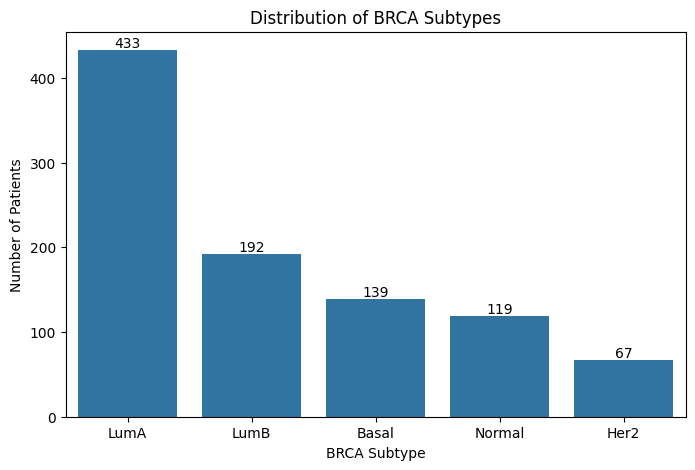

In [10]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=combined_clean, #weil die patienten ohne NaN nichts aussagen
    x="BRCA_subtype",
    order=combined_clean["BRCA_subtype"].value_counts().index
)

# Zahlen über Balken schreiben
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of BRCA Subtypes")
plt.xlabel("BRCA Subtype")
plt.ylabel("Number of Patients")

plt.show()

### Varianzen prüfen

In [11]:
# Features und Label trennen
X = combined_clean.drop(columns=["BRCA_subtype"])
y = combined_clean["BRCA_subtype"]

In [12]:
# Varianz jedes Gens berechnen
variances = X.var()

In [13]:
# Statistische Übersicht
print(variances.describe())

count    16383.000000
mean         1.239637
std          1.742989
min          0.000000
25%          0.279232
50%          0.595600
75%          1.528650
max         37.376686
dtype: float64


| Statistik       | Bedeutung                                       |
| --------------- | ----------------------------------------------- |
| `count = 16383` | so viele Gene/Fatures habt ihr                  |
| `min = 0`       | mindestens ein Gen hat exakt keine Varianz      |
| `25% = 0.279`   | 25 % aller Gene haben Varianz kleiner als 0.279 |
| `50% = 0.596`   | Medianvarianz                                   |
| `75% = 1.529`   | obere 25 % sind deutlich variabler              |
| `max = 37.37`   | einige Gene variieren extrem stark              |


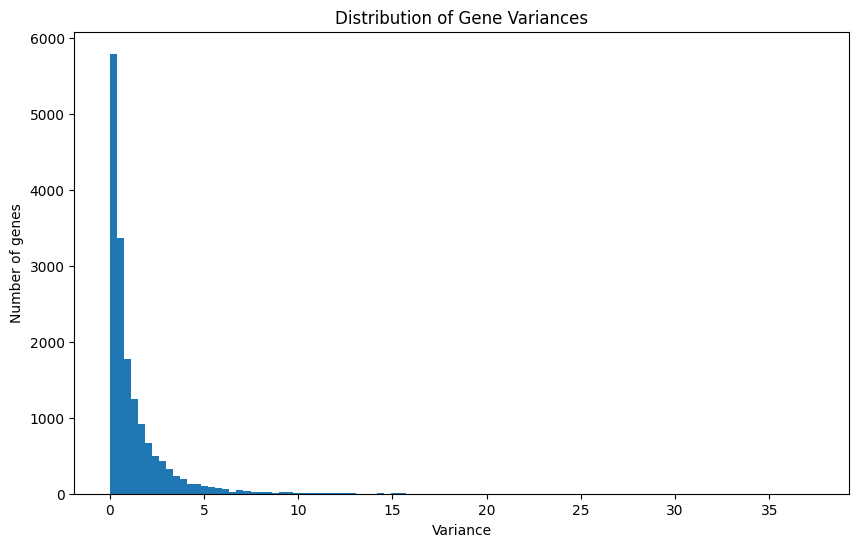

In [14]:
# Histogramm der Varianzen
plt.figure(figsize=(10,6))
plt.hist(variances, bins=100)

plt.xlabel("Variance")
plt.ylabel("Number of genes")
plt.title("Distribution of Gene Variances")

plt.show()

In [15]:
overview = pd.DataFrame({
    "variable": combined_clean.columns,
    "dtype": combined_clean.dtypes.astype(str).values,
    "n_unique": [combined_clean[col].nunique() for col in combined_clean.columns]
})

display(overview)


,variable,dtype,n_unique
0,ARHGEF10L,float64,931
1,HIF3A,float64,911
2,RNF17,float64,219
3,RNF10,float64,906
4,RNF11,float64,925
...,...,...,...
16379,HCG27,float64,934
16380,CYP2A13,float64,342
16381,CCR10,float64,937
16382,KDM4D,float64,932


In [16]:
#Standardabweichung / Varianz prüfen
gene_std = combined_clean.drop(columns="BRCA_subtype").std()
#.std(): Berechnet std : Wie stark streuuen die Werte um den Mittelwert
gene_std.sort_values().head(20)

#Output=0: überhaupt keine Streuung --> Alle Patienten haben exakt denselben Wert für dieses Gen --> Keine hilfreiche Info

SNORD113-4     0.0
TXNDC8         0.0
RBMY1A3P       0.0
SNORD88B       0.0
TTTY3B         0.0
SNORD115-2     0.0
SNORD115-3     0.0
SNORD116-13    0.0
TTTY6B         0.0
DAZ4           0.0
SNORD60        0.0
SNORD115-11    0.0
SNORD44        0.0
TSSK2          0.0
LOC653545      0.0
SNORD105       0.0
SNORD91A       0.0
SNAR-D         0.0
SNORA11C       0.0
SNORD115-16    0.0
dtype: float64

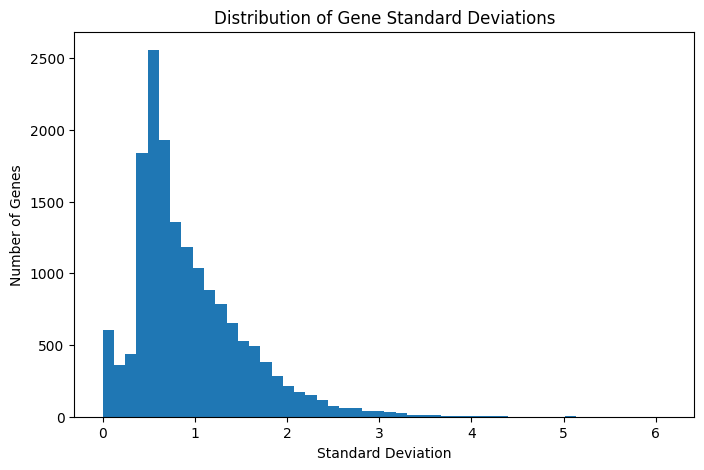

In [17]:
#Histogramm der Standardabweichungen
gene_std = combined_clean.drop(columns="BRCA_subtype").std()

plt.figure(figsize=(8,5))
plt.hist(gene_std, bins=50)
plt.xlabel("Standard Deviation")
plt.ylabel("Number of Genes")
plt.title("Distribution of Gene Standard Deviations")
plt.show()

In [18]:
#Um alle Gene mit n_unique = 1 zu sehen (also konstante Features), filterst du einfach dein overview-DataFrame:
constant_features = overview[overview["n_unique"] == 1]

display(constant_features)

,variable,dtype,n_unique
41,RBMY1A3P,float64,1
144,SNORD115-17,int64,1
283,SNORD114-31,int64,1
284,SNORD114-30,int64,1
297,SNORD115-6,int64,1
...,...,...,...
16160,SNORD60,int64,1
16198,TXNDC8,int64,1
16241,TTTY3B,int64,1
16315,KRTAP13-3,int64,1


In [19]:
# nur die Namen der Gene 
constant_gene_names = constant_features["variable"].tolist()

print(constant_gene_names)

['RBMY1A3P', 'SNORD115-17', 'SNORD114-31', 'SNORD114-30', 'SNORD115-6', 'SNORD115-4', 'SNORD104', 'SNORD115-9', 'SNORD38A', 'KRTAP19-7', 'KRTAP19-4', 'SNORD114-3', 'HBII-52-27', 'SNORD11', 'SNORD12', 'SNORD21', 'SNORD20', 'SNORD25', 'SNORD127', 'DAZ3', 'DAZ2', 'DAZ4', 'SNORD124', 'TTTY17A', 'SNORD115-5', 'SNORD80', 'SNORD56B', 'SNORD78', 'SNORD113-7', 'SNORD96A', 'SNORD119', 'HBII-52-46', 'HBII-52-45', 'SNORD47', 'SNORD4B', 'SNORD4A', 'SNORD116-24', 'SNORD116-25', 'SNORD116-23', 'SNORD116-29', 'RBMY1B', 'RBMY1F', 'BPY2', 'SNORD115-8', 'SNORD66', 'HBII-52-28', 'SNORD69', 'SNORD68', 'SNORD38B', 'SNORD113-4', 'SNORD116-26', 'SNORD115-1', 'SNORD58A', 'SNORD58C', 'PRR20A', 'PRR20D', 'SNORD96B', 'SNORD63', 'SNORD116-22', 'SNORD81', 'PLA2G2E', 'PRAMEF3', 'SNORD114-20', 'SNAR-A3', 'SNORD115-20', 'SNORD115-22', 'SNORD115-25', 'SNORD114-29', 'TEX28', 'CEACAM18', 'SNORD29', 'S100A7L2', 'LOC653545', 'SNORD16', 'SNORD36A', 'SNORD91B', 'SNORD87', 'SNORD86', 'DEFB116', 'DEFB114', 'DEFB112', 'TTTY4C',

In [20]:
#alle Gene mit n_unique=1
constant_features = overview[overview["n_unique"] == 1]

display(constant_features)

,variable,dtype,n_unique
41,RBMY1A3P,float64,1
144,SNORD115-17,int64,1
283,SNORD114-31,int64,1
284,SNORD114-30,int64,1
297,SNORD115-6,int64,1
...,...,...,...
16160,SNORD60,int64,1
16198,TXNDC8,int64,1
16241,TTTY3B,int64,1
16315,KRTAP13-3,int64,1


In [21]:
#anzahl der gene
print(len(constant_gene_names))
print(f"{len(constant_gene_names)} constant genes found.")

221
221 constant genes found.


In [22]:

#ohne konstante gene
constant_genes = gene_std[gene_std == 0].index #filtern alle gene mit std=0, index nnimmt nur deren Namen

combined_no_constant = combined_clean.drop(columns=constant_genes)



In [23]:
print(combined_clean.shape)
print(combined_no_constant.shape)

(950, 16384)
(950, 16163)


In [24]:
#prüfen ob keine konstanten features mehr vorhanden
combined_no_constant.drop(columns="BRCA_subtype").std().min()

np.float64(0.00853284675147811)

In [25]:
#finaler Analyse Datensatz --> cleaned (OHNE VAR=0 & OHNE NANs)
analysis = combined_no_constant.copy()

### Sampling vergleichen

In [26]:
target = "BRCA_subtype"
sample_frac = 0.2
n_repeats = 500

#normalize = True: wandelt absolute count in relative Häufigkeiten/ Anteile um
#Proportion=Anzahl Subtyp​/Gesamtzahl Patienten
#sort_index: sortiert alphabetisch nach labelnamen
original_props = analysis[target].value_counts(normalize=True).sort_index()
original_props

#Output: Propotinalen Anteile jedes Subtypens im gesamten Datensatz

BRCA_subtype
Basal     0.146316
Her2      0.070526
LumA      0.455789
LumB      0.202105
Normal    0.125263
Name: proportion, dtype: float64

In [27]:
#Simple Random Sampling mehrfach testen 
#misst wie stark weicht die Subtypen verteilung im Sample vom Original ab
simple_errors = []

for i in range(n_repeats):
    sample = analysis.sample(frac=sample_frac, random_state=i)
    sample_props = sample[target].value_counts(normalize=True).reindex(original_props.index, fill_value=0)
    #berechnet die Subtypen Proportionen des Samples
    error = (sample_props - original_props).abs().sum() #Wie stark weicht jede Klasse ab, abs. = absoluter wert
    simple_errors.append(error)

simple_mean_error = np.mean(simple_errors)# durchschnittliccher Sampling-Fehler
simple_mean_error

#Output: Im Durchschnitt weicht ein einfach zufällig gezogenes Sample 
# um etwa 9.5 Prozentpunkte Gesamtverteilung von der 
# ursprünglichen Subtyp-Verteilung ab.

np.float64(0.0950778947368421)

In [28]:
#stratefied sampling mehrfach testen
##misst wie stark weicht die Subtypen verteilung im Sample vom Original ab
strat_errors = []

for i in range(n_repeats):
    sample = (
        analysis
        .groupby(target, group_keys=False)
        .sample(frac=sample_frac, random_state=i)
    )
    
    sample_props = sample[target].value_counts(normalize=True).reindex(original_props.index, fill_value=0)
    error = (sample_props - original_props).abs().sum()
    strat_errors.append(error)

strat_mean_error = np.mean(strat_errors)
strat_mean_error

#Output: Die Verteilung eines stratified samples weicht im Durchschnitt nur um 0.79 Prozentpunkte Gesamtverteilung vom Originaldatensatz ab.

np.float64(0.008421052631578899)

In [29]:
#Vergleiche anzeigen
comparison = pd.DataFrame({
    "method": ["Simple random sampling", "Stratified sampling"],
    "mean_distribution_error": [simple_mean_error, strat_mean_error]
})

display(comparison)

#Stratified sampling erhält die ursprüngliche Subtyp-Verteilung besser.

,method,mean_distribution_error
0,Simple random sampling,0.095078
1,Stratified sampling,0.008421


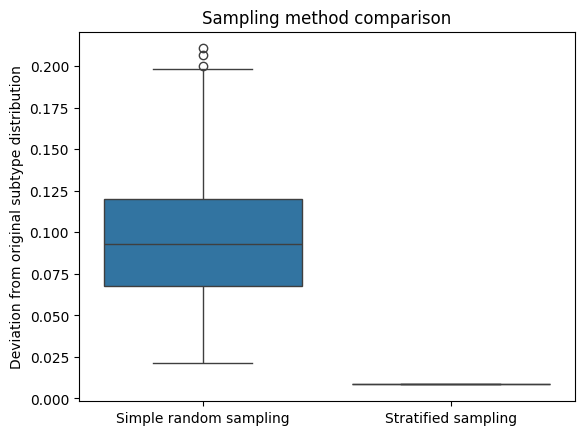

In [30]:
#visuell darstellen

error_df = pd.DataFrame({
    "Simple random sampling": simple_errors,
    "Stratified sampling": strat_errors
})

sns.boxplot(data=error_df)
plt.ylabel("Deviation from original subtype distribution")
plt.title("Sampling method comparison")
plt.show()

### Train/Test-Split

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
# Features und Labels
X = analysis.drop(columns=["BRCA_subtype"])
y = analysis["BRCA_subtype"]

In [33]:
# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #sorgt für rpoduzierbarkeit
    stratify=y #sampling art
)
#20 % test daten
#80% trainingsdaten

In [34]:
# Shapes kontrollieren
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (760, 16162)
X_test: (190, 16162)
y_train: (760,)
y_test: (190,)


In [35]:
#ob die Verteilungen ähnlich geblieben ist
print(y.value_counts(normalize=True))

print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

BRCA_subtype
LumA      0.455789
LumB      0.202105
Basal     0.146316
Normal    0.125263
Her2      0.070526
Name: proportion, dtype: float64
BRCA_subtype
LumA      0.455263
LumB      0.202632
Basal     0.146053
Normal    0.125000
Her2      0.071053
Name: proportion, dtype: float64
BRCA_subtype
LumA      0.457895
LumB      0.200000
Basal     0.147368
Normal    0.126316
Her2      0.068421
Name: proportion, dtype: float64


## Feature Selection

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

Während Splitting können neue Gene konstant werden

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

pipe_anova_logreg = Pipeline([
    ("variance", VarianceThreshold()),          #removes train-constant genes
    ("select", SelectKBest(score_func=f_classif, k=500)),  #selects top 500 genes | score_func=f_classif /mutual_info_classif
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_anova_logreg.fit(X_train, y_train)

pred_anova_logreg = pipe_anova_logreg.predict(X_test)

print(classification_report(y_test, pred_anova_logreg))

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.85      0.85      0.85        13
        LumA       0.92      0.91      0.91        87
        LumB       0.83      0.89      0.86        38
      Normal       0.92      0.92      0.92        24

    accuracy                           0.91       190
   macro avg       0.90      0.90      0.90       190
weighted avg       0.91      0.91      0.91       190



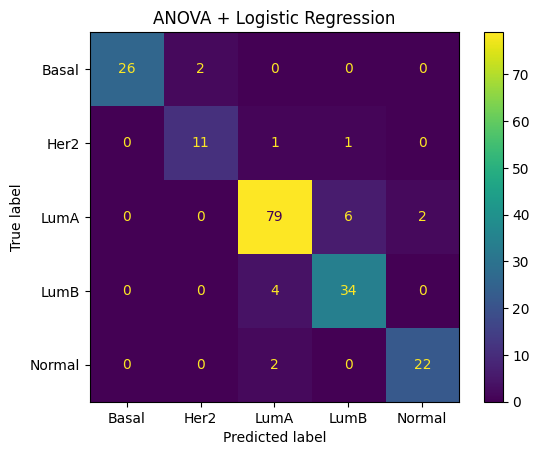

In [38]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred_anova_logreg)
plt.title("ANOVA + Logistic Regression")
plt.show()

#eventuell noch für LumA & LumB  optimieren

## Selected Genes ???

In [39]:
# get mask of selected features
selected_mask = pipe_anova_logreg.named_steps["select"].get_support()

# apply mask to original column names
selected_genes = X_train.columns[
    pipe_anova_logreg.named_steps["variance"].get_support()
][selected_mask]

selected_genes

Index(['HIF3A', 'LRRTM2', 'CAMKV', 'GTSE1', 'THSD4', 'CHST3', 'CHST2', 'GPSM2',
       'ZNF703', 'CKS1B',
       ...
       'KIAA1370', 'MMRN2', 'WDR67', 'CX3CL1', 'KCNK15', 'OVCH2', 'NCAPD2',
       'SLC6A14', 'FXYD1', 'KDM4B'],
      dtype='str', length=500)

In [40]:
#Baseline Logistic Regression (ohne Feature Selection)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print(classification_report(y_test, baseline_pred))



              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.67      0.77      0.71        13
        LumA       0.88      0.90      0.89        87
        LumB       0.76      0.76      0.76        38
      Normal       0.95      0.88      0.91        24

    accuracy                           0.86       190
   macro avg       0.85      0.85      0.85       190
weighted avg       0.87      0.86      0.86       190



In [41]:
# Comparison Table
from sklearn.metrics import accuracy_score, f1_score, recall_score

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_macro_f1 = f1_score(y_test, baseline_pred, average="macro")
baseline_her2_recall = recall_score(
    y_test,
    baseline_pred,
    labels=["Her2"],
    average=None
)[0]

print(baseline_accuracy)
print(baseline_macro_f1)
print(baseline_her2_recall)

0.8631578947368421
0.8479627373220049
0.7692307692307693


In [42]:
anova_accuracy = accuracy_score(y_test, pred_anova_logreg)
anova_macro_f1 = f1_score(y_test, pred_anova_logreg, average="macro")
anova_her2_recall = recall_score(
    y_test,
    pred_anova_logreg,
    labels=["Her2"],
    average=None
)[0]

print(anova_accuracy)
print(anova_macro_f1)
print(anova_her2_recall)

0.9052631578947369
0.8999675534284446
0.8461538461538461


In [43]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "ANOVA + Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        anova_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        anova_macro_f1
    ],
    "Her2 Recall": [
        baseline_her2_recall,
        anova_her2_recall
    ],
    "Number of Features": [
        X_train.shape[1],
        500
    ]
})

comparison

,Model,Accuracy,Macro F1,Her2 Recall,Number of Features
0,Baseline Logistic Regression,0.863158,0.847963,0.769231,16162
1,ANOVA + Logistic Regression,0.905263,0.899968,0.846154,500


### Hyperparameter Tuning

In [45]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)), #f_classif/mutual_info_classif
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "select__k": [50, 100, 200, 400, 500, 750, 1000, 2000],
    "model__C": [0.01, 0.1, 1, 10],
    #"model__l1_ratio": [0.05, 0.1, 0.3, 0.5, 0.7, 0.9] # Elastic Net Mischung
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best k:", grid.best_params_["select__k"])
print("Best C:", grid.best_params_["model__C"])
print("Best CV score:", grid.best_score_)

Best k: 400
Best C: 1
Best CV score: 0.9188957266200612


## Model Selection

zu testen:
LogRegCV |
LogRegEN |
RF |
SVM |
?KNN?

### Modelle definieren & trainieren
Mit Pipeline: "Pipeline allows you to sequentially apply a list of transformers to preprocess the data and, if desired, conclude the sequence with a final predictor for predictive modeling."

In [46]:
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    confusion_matrix
)

In [47]:
PREPROCESSING = [
    ("variance", VarianceThreshold()),
    ("select",   SelectKBest(score_func=f_classif, k=500)),
    ("scaler",   StandardScaler()),
]

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



#### 1) Logistic Regression mit L2-Regularisierung

In [48]:
# ── 1) Logistic Regression L2 ────────────────────────────────────────────────
pipe_lr = Pipeline(PREPROCESSING + [
    ("model", LogisticRegressionCV(
        Cs=np.logspace(-3, 1, 8),
        cv=5,
        penalty="l2",
        solver="lbfgs",
        scoring="balanced_accuracy",
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Trainiere LogReg L2 ...")
pipe_lr.fit(X_train, y_train)
print(f"  Bestes C: {pipe_lr.named_steps['model'].C_[0]:.4f}")
print("  Fertig.\n")

Trainiere LogReg L2 ...


c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=

  Bestes C: 0.0037
  Fertig.



#### 2) Logistic Regression mit Elastic Net

In [49]:
# ── 2) Logistic Regression Elastic Net ───────────────────────────────────────
pipe_en = Pipeline(PREPROCESSING + [
    ("model", LogisticRegressionCV(
        Cs=np.logspace(-3, 1, 8),
        cv=5,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.1, 0.5, 0.9],
        scoring="balanced_accuracy",
        class_weight="balanced",
        max_iter=3000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Trainiere Elastic Net ...")
pipe_en.fit(X_train, y_train)
print(f"  Bestes C:        {pipe_en.named_steps['model'].C_[0]:.4f}")
print(f"  Bestes l1_ratio: {pipe_en.named_steps['model'].l1_ratio_[0]:.2f}")
print("  Fertig.\n")

Trainiere Elastic Net ...


c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


  Bestes C:        0.1931
  Bestes l1_ratio: 0.10
  Fertig.



#### 3) Random Forest

In [50]:
# ── 3) Random Forest ─────────────────────────────────────────────────────────
pipe_rf = Pipeline(PREPROCESSING + [
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Trainiere Random Forest ...")
pipe_rf.fit(X_train, y_train)
print("  Fertig.\n")

Trainiere Random Forest ...
  Fertig.



#### 4) Support Vector Machine

In [51]:
# ── 4) SVM (GridSearchCV über C) ─────────────────────────────────────────────
base_svm = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,
    random_state=42
)

pipe_svm = Pipeline(PREPROCESSING + [
    ("model", GridSearchCV(
        estimator=base_svm,
        param_grid={"C": [0.001, 0.01, 0.1, 1, 10]},
        cv=cv_strategy,
        scoring="balanced_accuracy",
        n_jobs=-1,
        verbose=1
    ))
])

print("Trainiere SVM (GridSearchCV über C) ...")
pipe_svm.fit(X_train, y_train)
print(f"  Bestes C:        {pipe_svm.named_steps['model'].best_params_['C']}")
print(f"  Bestes CV-Score: {pipe_svm.named_steps['model'].best_score_:.4f}")
print("  Fertig.\n")

Trainiere SVM (GridSearchCV über C) ...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Bestes C:        0.01
  Bestes CV-Score: 0.9187
  Fertig.



### Evaluation auf dem Testset

In [52]:
# ── Alle Modelle evaluieren ────────────────────────────────────────────────
# Balanced Accuracy: Mittelwert der Recall-Werte pro Klasse --> berücksichtigt die Imbalance
# Wir sammeln Vorhersagen und Metriken für alle 4 Modelle in einem Dictionary

# ── Evaluation auf dem Testset ───────────────────────────────────────────────
pipelines = {
    "LogReg L2":     pipe_lr,
    "Elastic Net":   pipe_en,
    "Random Forest": pipe_rf,
    "SVM (linear)":  pipe_svm,
}

results = {}

for name, pipe in pipelines.items():
    print(f"\n{'─'*55}")
    print(f" {name}")
    print(f"{'─'*55}")
    y_pred = pipe.predict(X_test)
    ba = balanced_accuracy_score(y_test, y_pred)
    results[name] = {"pipe": pipe, "y_pred": y_pred, "balanced_acc": ba}
    print(f"Balanced Accuracy: {ba:.4f}\n")
    print(classification_report(y_test, y_pred))



───────────────────────────────────────────────────────
 LogReg L2
───────────────────────────────────────────────────────
Balanced Accuracy: 0.8745

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.69      0.85      0.76        13
        LumA       0.94      0.84      0.88        87
        LumB       0.73      0.84      0.78        38
      Normal       0.85      0.92      0.88        24

    accuracy                           0.86       190
   macro avg       0.84      0.87      0.85       190
weighted avg       0.88      0.86      0.87       190


───────────────────────────────────────────────────────
 Elastic Net
───────────────────────────────────────────────────────
Balanced Accuracy: 0.9029

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.80      0.92      0.86        13
        LumA       0.93      0.92      0.92 

### Übersicht & bestes Modell

In [53]:
# ── Vergleichstabelle ────────────────────────────────────────────────────────
comparison = (
    pd.DataFrame({
        "Modell":            list(results.keys()),
        "Balanced Accuracy": [v["balanced_acc"] for v in results.values()]
    })
    .sort_values("Balanced Accuracy", ascending=False)
    .reset_index(drop=True)
)
comparison.index += 1
comparison.index.name = "Rang"
print("\n" + "═"*45)
print(" MODELLVERGLEICH – Balanced Accuracy")
print("═"*45)
print(comparison.to_string())

best_model = comparison.iloc[0]["Modell"]
best_res  = results[best_model]["pipe"].named_steps["model"]
best_acc  = results[best_model]["balanced_acc"]

print(f"\n→ Bestes Modell: {best_model} ({best_acc:.4f})")


═════════════════════════════════════════════
 MODELLVERGLEICH – Balanced Accuracy
═════════════════════════════════════════════
             Modell  Balanced Accuracy
Rang                                  
1       Elastic Net           0.902922
2      SVM (linear)           0.898835
3         LogReg L2           0.874516
4     Random Forest           0.804069

→ Bestes Modell: Elastic Net (0.9029)


#### Confusion Matrices aller Modelle

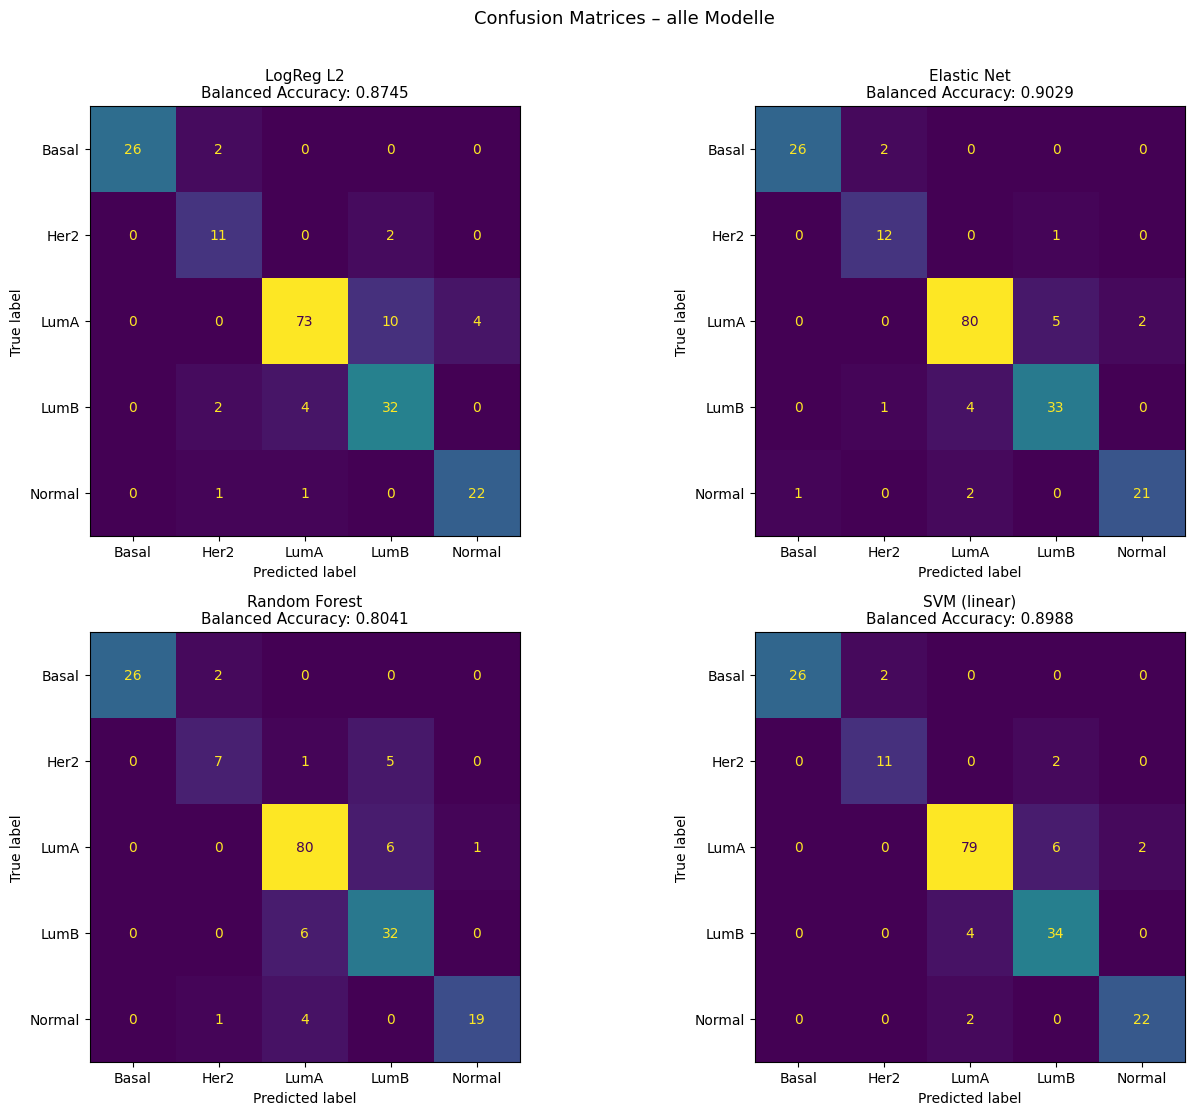

In [54]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
classes = best_res.classes_

for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(f"{name}\nBalanced Accuracy: {res['balanced_acc']:.4f}", fontsize=11)

plt.suptitle("Confusion Matrices – alle Modelle", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Feature Importance --> Wichtigste Gene

Je nach Modelltyp unterscheidet sich die Interpretation:
- **LogReg / Elastic Net**: Koeffizienten zeigen, welche Gene für welchen Subtyp sprechen
- **Random Forest**: Feature Importance (Gini) zeigt globale Wichtigkeit über alle Subtypen
- **SVM**: Koeffizientenvektor des linearen Kernels (entspricht den Gewichten der Hyperebene)

In [55]:
# ── Feature Importance des besten Modells ─────────────────────────────────
best_name  = comparison.iloc[0]["Modell"]          # z.B. "Elastic Net"
best_pipe  = results[best_name]["pipe"]             # die ganze Pipeline
best_clf   = best_pipe.named_steps["model"]         # nur der Classifier

# Gennamen nach VarianceThreshold + SelectKBest rekonstruieren
var_mask    = best_pipe.named_steps["variance"].get_support()
select_mask = best_pipe.named_steps["select"].get_support()
selected_genes = X_train.columns[var_mask][select_mask]

print(f"Feature-Analyse für: {best_name}\n")

if best_name in ("LogReg L2", "Elastic Net"):
    coef_df = pd.DataFrame(
        best_clf.coef_,
        index=best_clf.classes_,
        columns=selected_genes
    )
    print("Top 5 Gene pro Subtyp (nach absolutem Koeffizienten):")
    for subtype in best_clf.classes_:
        top5 = coef_df.loc[subtype].abs().sort_values(ascending=False).head(5)
        print(f"  {subtype}: {list(top5.index)}")

elif best_name == "Random Forest":
    importances = pd.Series(
        best_clf.feature_importances_,
        index=selected_genes
    ).sort_values(ascending=False)
    print("Top 10 Gene (Random Forest Feature Importance):")
    print(importances.head(10).to_string())

elif best_name == "SVM (linear)":
    # best_clf ist hier ein GridSearchCV-Objekt → .best_estimator_ holt die SVC
    svc = best_clf.best_estimator_
    coef_df = pd.DataFrame(svc.coef_, columns=selected_genes)
    print("Top 5 Gene mit grössten absoluten SVM-Gewichten (alle Klassen):")
    top_genes = coef_df.abs().max(axis=0).sort_values(ascending=False).head(5)
    print(top_genes.to_string())


Feature-Analyse für: Elastic Net

Top 5 Gene pro Subtyp (nach absolutem Koeffizienten):
  Basal: ['ZNF454', 'FOXC1', 'GDF5', 'GFRA3', 'RFC2']
  Her2: ['ESR1', 'FLJ45983', 'C20orf26', 'C6orf97', 'TRIM3']
  LumA: ['BCL2', 'RANBP1', 'NAT1', 'WDR67', 'DNMT3B']
  LumB: ['PPP1R14C', 'WDR67', 'STAC2', 'KLK6', 'KLK8']
  Normal: ['C20orf26', 'OXTR', 'GLRA4', 'CNN1', 'KCNMB1']


## Bestes Modell trainieren

aufpassen, dass Testset noch nicht gesehen
möglicherweise mit crossvalidation verbessern?
--> neues modell


Warum ein neues Modell und nicht einfach pipe_en verwenden?
 → Im Modellvergleich haben wir die Testset-Metriken aller 4 Modelle gesehen und anhand davon Elastic Net ausgewählt. Damit sind die Testdaten indirekt in die Modellauswahl eingeflossen (sog. "implicit leakage"). --> Um eine wirklich unverfälschte finale Zahl zu erhalten, setzen wir das Modell neu auf – mit denselben Hyperparametern, aber so, als hätten wir die Testdaten nie gesehen.

Woher kommen die Hyperparameter (C, l1_ratio)?
--> pipe_en hat intern via 5-Fold Cross Validation auf X_train die besten Werte gesucht. Diese CV-Ergebnisse sind sauber (kein Testset involviert), daher übernehmen wir C und l1_ratio direkt daraus.

In [56]:
# Beste Hyperparameter aus dem CV-Vergleich auslesen
# pipe_en.named_steps["model"] ist das LogisticRegressionCV-Objekt
best_C        = results["Elastic Net"]["pipe"].named_steps["model"].C_[0]
best_l1_ratio = results["Elastic Net"]["pipe"].named_steps["model"].l1_ratio_[0]

print(f"Übernommene Hyperparameter aus CV:")
print(f"  C        = {best_C:.4f}")
print(f"  l1_ratio = {best_l1_ratio:.2f}")
print()


Übernommene Hyperparameter aus CV:
  C        = 0.1931
  l1_ratio = 0.10



In [57]:
# ── Finales Modell definieren ─────────────────────────────────────────────────
# Identisches Preprocessing wie im Vergleich (VarianceThreshold → SelectKBest → Scaler)
# Jetzt aber LogisticRegression (nicht CV-Variante), weil die Hyperparameter
# bereits feststehen und nicht mehr gesucht werden müssen.

final_pipe = Pipeline([
    ("variance", VarianceThreshold()),                          # entfernt konstante Gene
    ("select",   SelectKBest(score_func=f_classif, k=500)),    # top 500 Gene via ANOVA
    ("scaler",   StandardScaler()),                             # z-Standardisierung
    ("model",    LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=best_C,                  # bestes C aus CV
        l1_ratio=best_l1_ratio,    # bestes l1_ratio aus CV
        class_weight="balanced",   # kompensiert Klassenimbalanz (Her2 selten)
        max_iter=3000,
        random_state=42
    ))
])

In [58]:
# ── Training ausschliesslich auf Trainingsdaten ───────────────────────────────
# X_train / y_train: die 80 % die das Modell sehen darf.
# X_test  / y_test:  werden erst im nächsten Schritt verwendet – einmalig.
print("Trainiere finales Modell auf X_train ...")
final_pipe.fit(X_train, y_train)
print("  Fertig.\n")


Trainiere finales Modell auf X_train ...


c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Fertig.



### hierarchischer Classifier

In [59]:
lum_mask = y_train.isin(["LumA", "LumB"])
X_lum = X_train[lum_mask]
y_lum = y_train[lum_mask]

lum_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(f_classif, k=400)),  # eigene Feature-Selection!
    ("model", LogisticRegression(
        C=0.1,                         # stärker regularisieren (ähnliche Klassen)
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

lum_pipe.fit(X_lum, y_lum)

c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [  813   814  1240  1707  2366  2646  3340  3490  4851  5166  5528  6484
  7858  9335  9848 10436 10465 10466 10556 12074 12195 12965 13248 13252
 14261 14862 15717 15933] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...001CA6879A200>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",400
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning th

In [60]:
def predict_hierarchical(X, main_pipe, lum_pipe, threshold=0.6):
    main_proba  = main_pipe.predict_proba(X)
    main_classes = main_pipe.classes_
    main_pred   = main_pipe.predict(X).copy()

    lum_a_idx = list(main_classes).index("LumA")
    lum_b_idx = list(main_classes).index("LumB")

    for i, pred in enumerate(main_pred):
        if pred in ["LumA", "LumB"]:
            # Nur LumA vs LumB Wahrscheinlichkeit betrachten
            p_luma = main_proba[i][lum_a_idx]
            p_lumb = main_proba[i][lum_b_idx]
            lum_confidence = max(p_luma, p_lumb) / (p_luma + p_lumb)
            
            if lum_confidence < threshold:
                # X schon durch main_pipe preprocessed übergeben
                final_pred[i] = lum_pipe.predict(X.iloc[[i]])[0]

    return main_pred

In [61]:
# ── Einmalige Evaluation auf dem Testset ─────────────────────────────────────
# Dies ist die einzige und letzte Berührung mit den Testdaten.
# Die resultierende Balanced Accuracy ist die offizielle finale Modellleistung.
final_pred = final_pipe.predict(X_test)
final_ba   = balanced_accuracy_score(y_test, final_pred)
final_accuracy = accuracy_score(y_test, final_pred)

print("══════════════════════════════════════════════")
print(" FINALES MODELL --- Evaluation auf dem Testset")
print("══════════════════════════════════════════════")
print(f"Balanced Accuracy: {final_ba:.4f}")
print(f"Accuracy: {final_accuracy:.4f}\n")
print(classification_report(y_test, final_pred))

══════════════════════════════════════════════
 FINALES MODELL --- Evaluation auf dem Testset
══════════════════════════════════════════════
Balanced Accuracy: 0.9029
Accuracy: 0.9053

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.80      0.92      0.86        13
        LumA       0.93      0.92      0.92        87
        LumB       0.85      0.87      0.86        38
      Normal       0.91      0.88      0.89        24

    accuracy                           0.91       190
   macro avg       0.89      0.90      0.90       190
weighted avg       0.91      0.91      0.91       190



## Ansätze zur weiteren Verbesserung:
#### Nach Aufwand geordnet:

1. Mehr Gene zulassen (einfachste Massnahme)
Du hast k=500 fixiert. Es wäre möglich, dass z.B. k=750 oder k=1000 bessere Resultate liefern. Das kannst du direkt im finalen Modell testen – den Wert via CV suchen, genau wie C und l1_ratio.

2. l1_ratio feiner tunen
Du hast nur drei Werte getestet: [0.1, 0.5, 0.9]. Ein feineres Grid wie [0.1, 0.3, 0.5, 0.7, 0.9] könnte einen besseren Mix finden – besonders relevant wegen der korrelierten Genstruktur.

3. LumA vs. LumB gezielt verbessern
Diese beiden Subtypen sind biologisch am ähnlichsten und wahrscheinlich die Hauptquelle der Fehler (das sieht man fast immer in BRCA-Confusion-Matrices). Ansätze:

     --> Andere Feature-Selection-Methode nur für dieses Paar, z.B. ein binärer Classifier oben drauf

    --> class_weight asymmetrisch anpassen

4. Andere Feature-Selection-Methode
ANOVA (f_classif) misst nur lineare Abhängigkeiten. Alternativen:

    --> mutual_info_classif – erkennt auch nichtlineare Zusammenhänge, dauert aber länger

    --> Recursive Feature Elimination (RFE) direkt mit Elastic Net – wählt Gene, die das Modell selbst als wichtig einstuft

5. Anderes Modell als Basis
Falls du bereit bist, Interpretierbarkeit aufzugeben:

    --> Gradient Boosting (z.B. XGBoost oder LightGBM) – oft stärker als lineare Modelle bei tabellarischen Daten

    --> Ensemble aus Elastic Net + SVM + RF via Voting – kombiniert die Stärken aller drei

#### ToDo für v4: Punkte 1, 2 und 3 von der ToDo-Liste angehen:

1 & 2: im Block LogisticRegressionCV anpassen

3

Abschliessend: Voting Classifier (letzter Punkt) mit Soft Voting

# FÜR ISA: ERSTER ANSATZ FÜR AUSWERTUNG

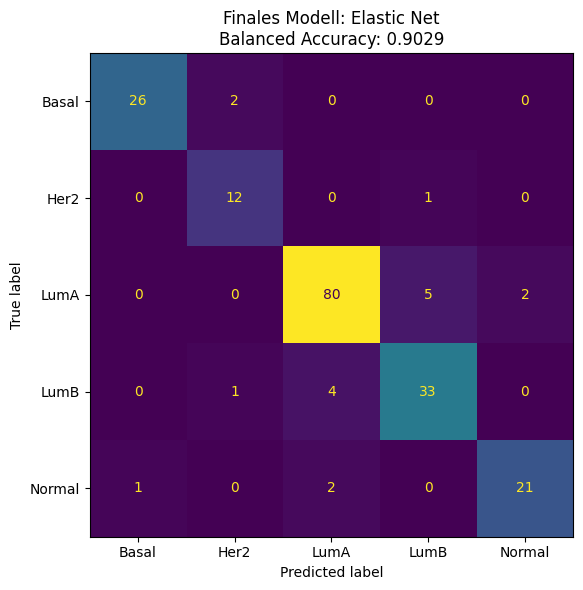

In [62]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred,
    ax=ax,
    colorbar=False
)
ax.set_title(
    f"Finales Modell: Elastic Net\nBalanced Accuracy: {final_ba:.4f}",
    fontsize=12
)
plt.tight_layout()
plt.show()